In [58]:
import os
import scipy
import numpy as np
import camb
import matplotlib.pyplot as plt
from os import path
from scipy import interpolate
from scipy.constants import pi
from scipy.optimize import curve_fit, fsolve, approx_fprime
from scipy.interpolate import RegularGridInterpolator
import scipy.integrate as integrate
from camb import model, initialpower
from scipy.integrate import cumulative_trapezoid
import matplotlib.cm as cm
import matplotlib.lines as mlines

from matplotlib.lines import Line2D
from matplotlib import cm, colors as mcolors, rcParams
from matplotlib.ticker import FixedLocator, FuncFormatter, AutoMinorLocator, MaxNLocator
from scipy.integrate import simpson
from scipy.interpolate import interp1d
from scipy import special as sps
from scipy.stats import chi2
import hashlib
import camb


In [59]:
CHIME_survey_config= {"zstar": 1, 
    "alpha": 0.1,
    "b_e": 1.0,
    "b_f": 1.5,
    "log_k_cut": np.log(1.65),
    "n_frb": 1630,
    "f_sky": 0.275,
    "n_g": 5.8e6,
    "frb_dist_model": "schechter",
    "galaxy_dist_model": "CHIME"}

active_survey_cfg = CHIME_survey_config

B_E = CHIME_survey_config['b_e']
LOG_K_CUT = CHIME_survey_config['log_k_cut']
B_F = CHIME_survey_config["b_f"]
ZSTAR = CHIME_survey_config['zstar']
ALPHA = CHIME_survey_config['alpha']

In [90]:
HUBBLE_DISTANCE = 2997.92458 #Mpc/h

OMEGA_M = 0.3
OMEGA_R = 4.15e-5     
OMEGA_L =  1 - OMEGA_M - OMEGA_R    # Assumes a flat universe

OMEGA_BH2 = 0.022447
FD = 0.844
YHE = 0.245
RHOC_OVER_H2 = 1.879e-29    # g/cm3 (D&S p465)
MP = 1.672621e-24     # g

LITTLE_H = 0.6770

def solve_friedmann(return_extra=False):
    """Integrates Friedmann equation and returns an interpolator for results.

    Returns
    -------
    conformal_distance_interpolator : callable with argument z
        Units Mpc/h

    looks like it's giving back comoving distance
    which is consistent with the paper/the rest of the results, but not 
    "conformal distance"

    """

    # Integration step edges.d
    a = np.logspace(-3., 0, 5000, endpoint=True)
    # Integration step centres.
    da = np.diff(a)
    a_c = a[1:] - da / 2 
    # Upper edges.
    a = a[1:]
    z = 1/a - 1

    tH0 = np.cumsum(dtH0_da(a_c) * da)
    etaH0 = np.cumsum(detaH0_da(a_c) * da)
    hubble_parameter = 1. / a / dtH0_da(a) / HUBBLE_DISTANCE  # h/Gpc
    comoving_hubble_parameter = hubble_parameter * a

    conformal_distance = (etaH0[-1] - etaH0) * HUBBLE_DISTANCE
    if return_extra:
        dz_dchi = np.gradient(z, conformal_distance)
        dz_dchi_interp = interpolate.interp1d(z, dz_dchi, kind='cubic')
        return interpolate.interp1d(z, conformal_distance, kind='cubic'), \
                interpolate.interp1d(conformal_distance, z, kind='cubic'),\
                dz_dchi_interp
                
    return interpolate.interp1d(z, conformal_distance, kind='cubic')

def detaH0_da(a): # expression for deta/da, times H0
    return dtH0_da(a) / a

def dtH0_da(a): # expression for dt/da, times H0
    return 1. / np.sqrt(OMEGA_R / a**2 + OMEGA_M / a + OMEGA_L * a**2)

# initiate power spectra
# use class for the non-linear power spectra
import camb
h = 0.6770
ombh2 = 0.0486 * h**2
omch2 = (0.3089 - 0.0486) * h**2
z_pk = np.linspace(0, 5, 100)
# print(z_pk)
pars = camb.CAMBparams()
pars.set_cosmology(H0=100.0 * h, ombh2=ombh2, omch2=omch2, mnu=0.06, tau=0.0568)
pars.InitPower.set_params(As=2.107e-9, ns=0.9682)
pars.set_matter_power(redshifts=z_pk, kmax=50.0)
pars.NonLinear = model.NonLinear_both      # halofit
results = camb.get_results(pars)

kh, z_eval, pk_table = results.get_matter_power_spectrum(
minkh=1e-4, maxkh=40.0, npoints=200
)

pk_interp = scipy.interpolate.RegularGridInterpolator((z_eval, kh), pk_table)
z_lo, z_hi = z_eval[0], z_eval[-1]
k_lo, k_hi = kh[0], kh[-1]

def Pk_NL(z, k):
    k_arr = np.atleast_1d(k)
    z_arr = np.broadcast_to(np.atleast_1d(z), k_arr.shape)
    # clip into table support: high-k is exp-suppressed by the k_cut anyway
    k_arr = np.clip(k_arr, k_lo, k_hi)
    z_arr = np.clip(z_arr, z_lo, z_hi)
    pts = np.column_stack([z_arr, k_arr])
    out = pk_interp(pts)
    # preserve input shape: scalar in -> scalar out, array in -> array out
    if np.ndim(k) == 0 and np.ndim(z) == 0:
        return out[0]
    return out.reshape(np.shape(k) if np.ndim(k) else np.shape(z))



# initiate power spectra of different tracers
# get the auto- and cross- power spectra for galaxies and electrons, as inspired by the halo model
# adjust using a fixed value of h! the original defns are all with k in h/Mpc, and returns power spectra in Mpc^3/h^3
b_g = active_survey_cfg.get("b_g", 1.2)
# NOTE: b_g is read from the active survey config at module-load time; the Pgg/Peg/Pfg
# closures look it up in the module namespace at call time, so you can override it
# post-import via `fxg.b_g = <value>` before running a Fisher forecast.
def Pee(z, k, b_e=B_E, log_k_cut=LOG_K_CUT):
    return Pk_NL(z, k) * b_e**2 * np.exp(-k/np.exp(log_k_cut)) 

def Peg(z, k, b_e=B_E, log_k_cut=LOG_K_CUT):
    return Pk_NL(z, k) * b_e * np.exp(-k/np.exp(log_k_cut))*b_g 
    
def Pgg(z, k):
    return Pk_NL(z, k) * b_g**2 

def Pff(z, k, b_f=B_F):
    return Pk_NL(z, k) * b_f**2 

def Pef(z, k, b_e=B_E, log_k_cut=LOG_K_CUT, b_f=B_F):
    return Pk_NL(z, k) * b_e*b_f*np.exp(-k/np.exp(log_k_cut))

def Pfg(z, k, b_f=B_F):
    return Pk_NL(z, k) * b_f*b_g

# k range and fixed redshift
k_vals = np.logspace(-2, 1, 300)
z_fixed = 0.5

# Compute power spectra
# Pee_vals = Pee(z_fixed, k_vals)
# Peg_vals = Peg(z_fixed, k_vals)
# Pgg_vals = Pgg(z_fixed, k_vals)

# evaluate the signal with some dummy values
chi_of_z, z_of_chi, dzdchi = solve_friedmann(return_extra=True) 
n_e0 = 0.24203
z_cosmo = z_of_chi
N_G_GAL_NORM = 1
Z_MIN_GAL = 0.1
Z_MAX_GAL = 0.6
DIST_MIN, DIST_MAX, N_INT = 50, 6e3, 150

chi_vals = np.linspace(0, DIST_MAX, 1000) 

Note: redshifts have been re-sorted (earliest first)


In [91]:
print(b_g)

1.2


In [92]:
def precompute_cosmo():
    """
    Build a reusable package of arrays and interpolators that do NOT depend on alpha or zstar.
    """

    z_grid = np.linspace(0.01, 6, 1000)
    chi_grid = chi_of_z(z_grid)
    dl_grid = (1+z_grid) * chi_grid

    dl_of_z = interpolate.interp1d(z_grid, dl_grid, kind='cubic')
    

    return dict(z_grid=z_grid, chi_grid=chi_grid, dl_grid=dl_grid, dchi_dz=1/dzdchi(z_grid),
                z_of_chi=z_of_chi, dl_of_z=dl_of_z, dchidz_of_z=lambda z: 1/ dzdchi(z))


In [93]:
def _upper_incgamma(a, x):
    """Upper incomplete gamma Γ(a, x) with safe handling for a∈(-1,0], a>0."""
    if a > 0:
        return sps.gammaincc(a, x) * sps.gamma(a)  # Q(a,x)*Γ(a)
    if np.isclose(a, 0.0):
        # Γ(0, x) = E1(x) = -Ei(-x)
        return -sps.expi(-x)
    if (-1.0 < a) and (a < 0.0):
        # Γ(a, x) = (Γ(a+1, x) - x^a e^{-x}) / a
        return (_upper_incgamma(a + 1.0, x) - np.exp(-x) * x**a) / a
    # For a <= -1, a rigorous model needs a hard low-L cutoff; provide a gentle continuation:
    eps = 1e-6
    return sps.gammaincc(a + eps, x) * sps.gamma(a + eps)

def _schechter_cumulative_above(alpha, x_min):
    """
    ∫_{x_min}^∞ x^α e^{-x} dx = Γ(α+1, x_min), with branches to cover α+1 ≤ 0.
    """
    a = alpha + 1.0
    return _upper_incgamma(a, x_min)
# --------------------------
# 3) Factory: build n_f_dist(chi, alpha, zstar)
# --------------------------
#def make_n_f_dist(pre):
"""
Returns a callable n_f_dist(chi, alpha, zstar) that computes
pf(chi) = (1/Nf) dN/dχ, normalized so ∫ pf(χ) dχ = 1.
"""
pre = precompute_cosmo()

z_grid      = pre["z_grid"]
chi_grid    = pre["chi_grid"]
dl_grid     = pre["dl_grid"]
dchi_dz     = pre["dchi_dz"]
dl_of_z     = pre["dl_of_z"]

# internal: normalized n(z), then pf(chi) = 4πχ^2 n(z) / (∫ 4πχ^2 n dχ)
def _n_z_norm(zstar, alpha):
    dL_star = float(dl_of_z(zstar))
    x_min   = (dl_grid / dL_star)**2
    n_un    = _schechter_cumulative_above(alpha, x_min)   # up to overall φ*
    # Normalize in χ-space: ∫ 4π χ^2 n(z) dχ = ∫ 4π χ^2 n(z) (dχ/dz) dz
    denom = simpson(4.0*np.pi*chi_grid**2 * n_un * dchi_dz, z_grid)
    return n_un / denom

N_F_DIST_PRECOMP_GRID = dict()



def n_f_dist(chi, zstar=ZSTAR, alpha=ALPHA):
    """
    Return pf(chi) = (1/Nf) dN/dχ on the provided χ-array.
    This is the χ-space weight used in your correlation (units h/Mpc).
    """

    # map χ -> z on the precomputed grid
    z = z_of_chi(chi)
    # evaluate normalized n(z) on the precomputed z_grid, then interpolate to z(chi)
    if f"{zstar}_{alpha}" in N_F_DIST_PRECOMP_GRID:
        n_norm_grid = N_F_DIST_PRECOMP_GRID[f"{zstar}_{alpha}"]
    else:
        n_norm_grid = _n_z_norm(zstar, alpha)
        N_F_DIST_PRECOMP_GRID[f"{zstar}_{alpha}"] = n_norm_grid
    n_of_z = np.interp(z, z_grid, n_norm_grid, left=0.0, right=0.0)
    # pf(χ) = 4π χ^2 n(z) / Nf, but since n was normalized to make ∫ 4πχ^2 n dχ = 1,
    # this is already a normalized χ-PDF: ∫ pf(χ) dχ = 1.
    pf_chi = 4.0 * np.pi * chi**2 * n_of_z
    return pf_chi

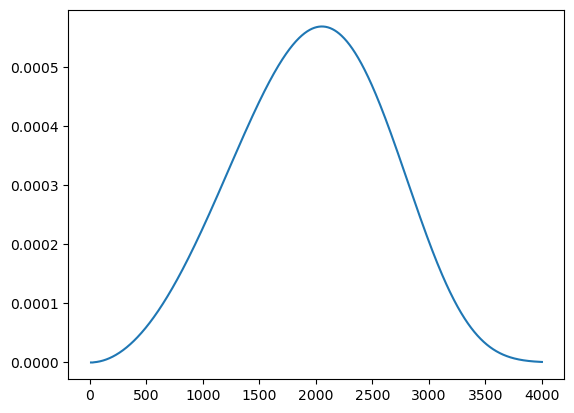

In [94]:
chi_plot = np.linspace(10, 4000, 1000)
plt.plot(chi_plot, n_f_dist(chi_plot))

In [95]:
def n_g_dist_maker_CHIME(galaxy_z_path=None):
    #galaxy_z_path = "./"
    galaxy_z_dist = np.load(galaxy_z_path)
    p_g = interpolate.interp1d(
        galaxy_z_dist[0],       # z grid
        galaxy_z_dist[1],       # cumulative values
        kind='linear',
        bounds_error=False,     # avoid ValueError for out-of-bounds
        fill_value=(0.0, 1.0)   # use 0 for z < z_min, 1 for z > z_max
    )
    return interpolate.interp1d(
        chi_vals,
        np.gradient(p_g(z_of_chi(chi_vals)), chi_vals),
        kind='cubic',
        bounds_error=False,
        fill_value=0.0
    )

In [96]:
n_g_dist = n_g_dist_maker_CHIME("./bgs_nz_cdf.npy")

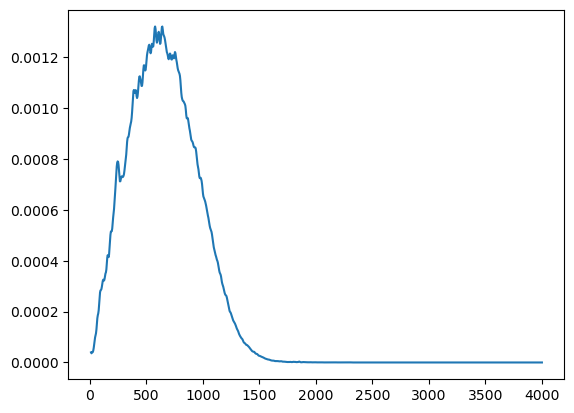

In [97]:
chi_plot = np.linspace(10, 4000, 1000)
plt.plot(chi_plot, n_g_dist(chi_plot))

In [98]:
MU_HOST, SIGMA_HOST = 100, 100
def p_host(D, chi, muR_unscaled=MU_HOST, sigmaR2_unscaled=SIGMA_HOST**2):
    """
    Lognormal host DM PDF p(D | chi) with vectorized support.
    Returns 0 for D <= 0, handles scalar or array D and chi via broadcasting.
    """
    # Convert inputs to arrays for consistent broadcasting
    D = np.asarray(D, dtype=float)
    z = np.asarray(z_of_chi(chi), dtype=float)

    # Redshift-scaled real mean and variance of the lognormal
    muR     = muR_unscaled / (1.0 + z)
    sigmaR2 = sigmaR2_unscaled / (1.0 + z)**2

    # Lognormal parameters in log-space
    sigma2 = np.log(sigmaR2 / (muR**2) + 1.0)     # variance of ln D
    mu     = np.log(muR) - 0.5 * sigma2           # mean of ln D

    # Broadcast D, mu, sigma2 to a common shape
    D_b, mu_b, s2_b = np.broadcast_arrays(D, mu, sigma2)

    # Output initialized to zero so D<=0 is already handled
    out = np.zeros_like(D_b, dtype=float)

    # Mask positive support; avoid D=0 singularity
    mask = D_b > 0.0
    if np.any(mask):
        Dm  = D_b[mask]
        mum = mu_b[mask]
        s2m = s2_b[mask]

        # PDF of the lognormal
        out[mask] = (1.0 / (Dm * np.sqrt(s2m) * np.sqrt(2.0*np.pi))
                    * np.exp(-(np.log(Dm) - mum)**2 / (2.0*s2m)))

    # Return a scalar if the input was scalar for convenience
    return out.item() if out.shape == () else out

def mu_host_func(chi, muR=MU_HOST, disable_z_evolve=False):
    if disable_z_evolve: return muR
    z = z_of_chi(chi)
    return muR/(1+z)

In [99]:
chi_vals = np.linspace(0, 6000, 1000)
z_vals = z_of_chi(chi_vals)

# Compute integrand: (1 + z(chi)) * n_e0
integrand = (1 + z_vals) * n_e0

# Compute D(chi) via cumulative integral
D_vals = cumulative_trapezoid(integrand, chi_vals, initial=0)

D_of_chi = interpolate.interp1d(chi_vals, D_vals, kind='cubic')

In [100]:
chi_int = np.geomspace(DIST_MIN, DIST_MAX, N_INT)
def frb_weight_dm_integrand(chi):
    return n_f_dist(chi) * (D_of_chi(chi) + mu_host_func(chi))
FRB_WEIGHT_DM = integrate.simpson(frb_weight_dm_integrand(chi_int), chi_int)
FRB_WEIGHT_DM

np.float64(741.3826978844928)

In [101]:
def Dxg(
    l,
    z_g,
    zstar=ZSTAR,
    alpha=ALPHA,
    b_e=B_E,
    b_f=B_F,
    log_k_cut=LOG_K_CUT,
    mu_host=MU_HOST,
    D_f_external=None,
    return_parts=False
):
    chi_g = chi_of_z(z_g)
        
    prefactor1 = n_e0 * (1+z_g) * Peg(z=z_g, k=l/chi_g, b_e=b_e, log_k_cut=log_k_cut)/chi_g**2  # Compare with equation (6)

    def integrand_1(chi):
        return n_f_dist(chi, zstar, alpha)
    chi_vals_gmax = np.linspace(chi_g, DIST_MAX, N_INT) # Integrating dzp_f(z) to get f_f
    term1 = prefactor1 * integrate.simpson(integrand_1(chi_vals_gmax), chi_vals_gmax)

    prefactor2 = n_f_dist(chi_g, zstar, alpha) * Pfg(z=z_g, k=l/chi_g, b_f=b_f)/chi_g**2

    # def integrand_2(chi):
    #     return n_f_dist(chi, zstar=ZSTAR, alpha=ALPHA) * (D_of_chi(chi) + mu_host_func(chi, muR=mu_host, disable_z_evolve=disable_z_evolve))

    # chi_vals = np.linspace(DIST_MIN, DIST_MAX, N_INT*100)
    # D_f = integrate.simpson(integrand_2(chi_vals), chi_vals)
    # Keep D_f externally fixed by default (measured from data).
    D_f = FRB_WEIGHT_DM if D_f_external is None else float(D_f_external)

    term2 = prefactor2 * (D_of_chi(chi_g) + mu_host_func(chi_g, muR=mu_host) - D_f)

    if return_parts:
        return term1, term2
    return term1 + term2
    

In [102]:
def cl_model (ell, dxg, l_cut= 4000):
    return  dxg * np.exp(-ell**2 / (2*l_cut**2))

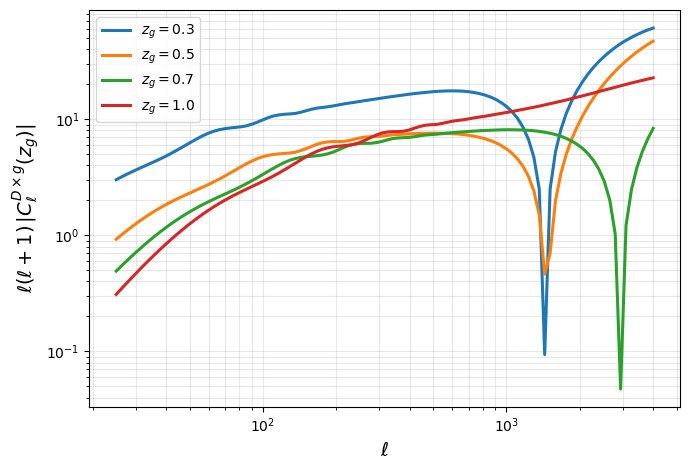

In [103]:
ells = np.geomspace(25, 4000, 100)
z_g_vals = [0.3, 0.5, 0.7, 1.0]

plt.figure(figsize=(7.0, 4.8))
for z_g in z_g_vals:
    cl = np.array([Dxg(ell, z_g=z_g) for ell in ells])
    plt.plot(ells, np.abs(ells * (ells + 1) * cl), lw=2.2, label=rf"$z_g={z_g:.1f}$")

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\ell$", fontsize=14)
plt.ylabel(r"$\ell(\ell+1)\,|C_\ell^{D\times g}(z_g)|$", fontsize=14)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


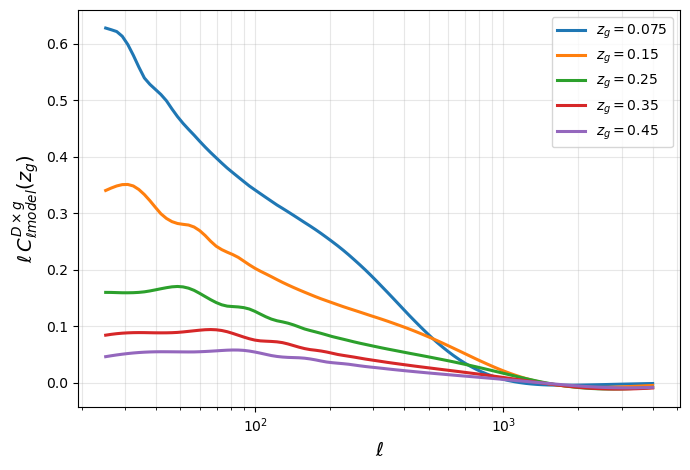

In [104]:
ells = np.geomspace(25, 4000, 100)
z_g_vals = [0.075, 0.150, 0.250, 0.350, 0.450]

plt.figure(figsize=(7.0, 4.8))
for z_g in z_g_vals:
    cls = np.array([Dxg(ell, z_g=z_g) for ell in ells])
    cl_mod = cls * np.exp(-(ells**2) / (2*4000**2))
    plt.plot(ells, (ells * cl_mod), lw=2.2, label=rf"$z_g={z_g:.3}$")

plt.xscale("log")
plt.xlabel(r"$\ell$", fontsize=14)
plt.ylabel(r"$\ell\,C_{\ell model}^{D\times g}(z_g)$", fontsize=14)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [25]:
print(np.exp(-ells**2 / (2*4000**2)))

[0.99998047 0.99997836 0.99997602 0.99997344 0.99997057 0.99996739
 0.99996387 0.99995997 0.99995565 0.99995086 0.99994555 0.99993967
 0.99993316 0.99992594 0.99991795 0.99990909 0.99989927 0.9998884
 0.99987635 0.999863   0.99984821 0.99983182 0.99981366 0.99979355
 0.99977126 0.99974656 0.99971921 0.99968889 0.99965531 0.9996181
 0.99957688 0.9995312  0.9994806  0.99942454 0.99936242 0.99929361
 0.99921737 0.99913291 0.99903933 0.99893567 0.99882082 0.99869359
 0.99855264 0.99839649 0.99822351 0.9980319  0.99781963 0.99758451
 0.99732406 0.99703557 0.99671603 0.9963621  0.99597011 0.99553598
 0.9950552  0.99452278 0.99393321 0.99328039 0.99255758 0.99175735
 0.99087147 0.98989087 0.98880553 0.98760439 0.98627527 0.98480473
 0.98317799 0.98137874 0.97938907 0.9771893  0.97475778 0.9720708
 0.96910235 0.965824   0.96220462 0.95821031 0.95380409 0.9489458
 0.94359185 0.9376951  0.93120472 0.92406602 0.91622045 0.90760557
 0.8981551  0.88779915 0.87646445 0.86407488 0.85055202 0.83581612